In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 10

# K-Nearest Neighbors (KNN) Regression

---

### Objectives

- Load Dataset
- Feature Scaling
- Train KNN Regressor
- Evaluate Performance
- Save Model

In [ ]:
# ==============================================================================
# INSTALL REQUIRED LIBRARIES
# ==============================================================================

# Uncomment if required

# %pip install scikit-learn
# %pip install joblib

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [5]:
# ==============================================================================
# LOAD DATASET
# ==============================================================================

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\retail_cleaned.csv")

print("Dataset Shape :",df.shape)

Dataset Shape : (8601, 33)


In [6]:
# ==============================================================================
# DEFINE TARGET
# ==============================================================================

TARGET="Sales"

X=df.drop(columns=[TARGET])

y=df[TARGET]

In [7]:
# ==============================================================================
# REMOVE UNUSED COLUMNS
# ==============================================================================

if "Date" in X.columns:
    X.drop(columns=["Date"], inplace=True)

if "Sales_Per_Customer" in X.columns:
    X.drop(columns=["Sales_Per_Customer"], inplace=True)

print(X.shape)

(8601, 30)


In [8]:
# ==============================================================================
# LABEL ENCODING
# ==============================================================================

encoder=LabelEncoder()

for col in X.select_dtypes(include="object").columns:

    X[col]=encoder.fit_transform(X[col])

print("Encoding Completed")

Encoding Completed


In [9]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print("Training Shape :",X_train.shape)

print("Testing Shape :",X_test.shape)

Training Shape : (6880, 30)
Testing Shape : (1721, 30)


In [10]:
# ==============================================================================
# FEATURE SCALING
# ==============================================================================

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [11]:
# ==============================================================================
# CREATE KNN MODEL
# ==============================================================================

knn_model=KNeighborsRegressor(

    n_neighbors=5,

    weights="distance",

    metric="minkowski",

    p=2

)

print(knn_model)

KNeighborsRegressor(weights='distance')


In [12]:
# ==============================================================================
# TRAIN MODEL
# ==============================================================================

knn_model.fit(

    X_train,

    y_train

)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [13]:
# ==============================================================================
# TRAIN PREDICTIONS
# ==============================================================================

y_train_pred=knn_model.predict(X_train)

In [14]:
# ==============================================================================
# TEST PREDICTIONS
# ==============================================================================

y_test_pred=knn_model.predict(X_test)

In [15]:
# ==============================================================================
# MODEL EVALUATION
# ==============================================================================

mae=mean_absolute_error(y_test,y_test_pred)

mse=mean_squared_error(y_test,y_test_pred)

rmse=np.sqrt(mse)

r2=r2_score(y_test,y_test_pred)

print("MAE :",round(mae,2))
print("MSE :",round(mse,2))
print("RMSE :",round(rmse,2))
print("R² :",round(r2,4))

MAE : 20.99
MSE : 750.21
RMSE : 27.39
R² : 0.7364


In [16]:
# ==============================================================================
# PERFORMANCE TABLE
# ==============================================================================

performance=pd.DataFrame({

    "Metric":["MAE","MSE","RMSE","R²"],

    "Value":[mae,mse,rmse,r2]

})

performance

,Metric,Value
0,MAE,20.988313
1,MSE,750.209222
2,RMSE,27.389947
3,R²,0.736415


In [17]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

prediction_df=pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_test_pred,

    "Error":y_test-y_test_pred

})

prediction_df.head(20)

,Actual,Predicted,Error
5839,6,25.838424,-19.838424
4275,91,130.668286,-39.668286
6086,49,39.426825,9.573175
8265,90,105.467755,-15.467755
5493,15,56.241545,-41.241545
1688,127,64.536298,62.463702
5241,59,61.030032,-2.030032
221,53,82.274032,-29.274032
239,63,76.454073,-13.454073
2208,53,58.579242,-5.579242


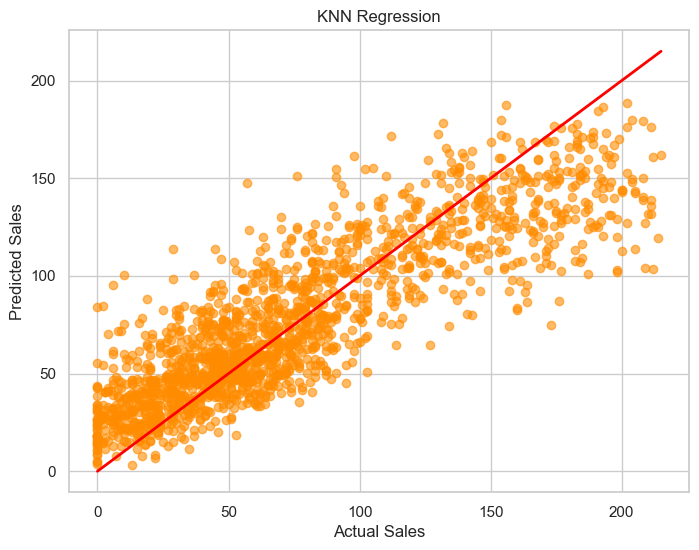

In [18]:
# ==============================================================================
# ACTUAL VS PREDICTED SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_test_pred,

    alpha=0.6,

    color="darkorange"

)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("KNN Regression")

plt.show()

In [19]:
# ==============================================================================
# RESIDUALS
# ==============================================================================

prediction_df["Residual"]=prediction_df["Actual"]-prediction_df["Predicted"]

prediction_df.head()

,Actual,Predicted,Error,Residual
5839,6,25.838424,-19.838424,-19.838424
4275,91,130.668286,-39.668286,-39.668286
6086,49,39.426825,9.573175,9.573175
8265,90,105.467755,-15.467755,-15.467755
5493,15,56.241545,-41.241545,-41.241545


In [21]:
# ==============================================================================
# TRAINING R² SCORE
# ==============================================================================

train_r2 = r2_score(y_train, y_train_pred)

print("Training R² Score :", round(train_r2,4))

Training R² Score : 1.0


In [22]:
# ==============================================================================
# TESTING R² SCORE
# ==============================================================================

test_r2 = r2_score(y_test, y_test_pred)

print("Testing R² Score :", round(test_r2,4))

Testing R² Score : 0.7364


In [23]:
# ==============================================================================
# ADJUSTED R² SCORE
# ==============================================================================

n = X_test.shape[0]

p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print("Adjusted R² :", round(adjusted_r2,4))

Adjusted R² : 0.7317


In [24]:
# ==============================================================================
# MEAN ABSOLUTE PERCENTAGE ERROR (MAPE)
# ==============================================================================

mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("MAPE :", round(mape,2), "%")

MAPE : inf %


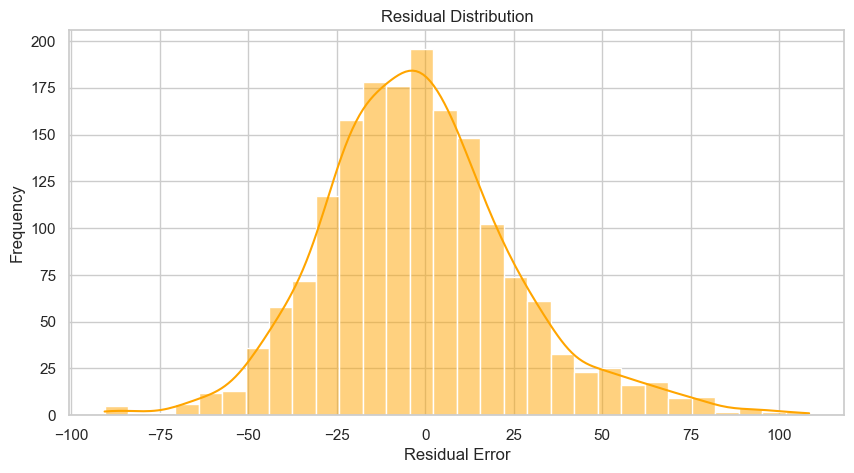

In [25]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    prediction_df["Residual"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.show()

In [26]:
# ==============================================================================
# CROSS VALIDATION
# ==============================================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    KNeighborsRegressor(
        n_neighbors=5,
        weights="distance",
        metric="minkowski",
        p=2
    ),

    scaler.fit_transform(X),

    y,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

print("Cross Validation Scores")

print(cv_scores)

Cross Validation Scores
[0.76275031 0.74626653 0.73890621 0.75930136 0.71977428]


In [27]:
# ==============================================================================
# AVERAGE CROSS VALIDATION SCORE
# ==============================================================================

print("Average CV Score :", round(cv_scores.mean(),4))

Average CV Score : 0.7454


In [28]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

summary = pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adjusted R²",
        "MAPE",
        "Cross Validation"
    ],

    "Value":[
        mae,
        mse,
        rmse,
        test_r2,
        adjusted_r2,
        mape,
        cv_scores.mean()
    ]

})

summary

,Metric,Value
0,MAE,20.988313
1,MSE,750.209222
2,RMSE,27.389947
3,R²,0.736415
4,Adjusted R²,0.731736
5,MAPE,inf
6,Cross Validation,0.745400


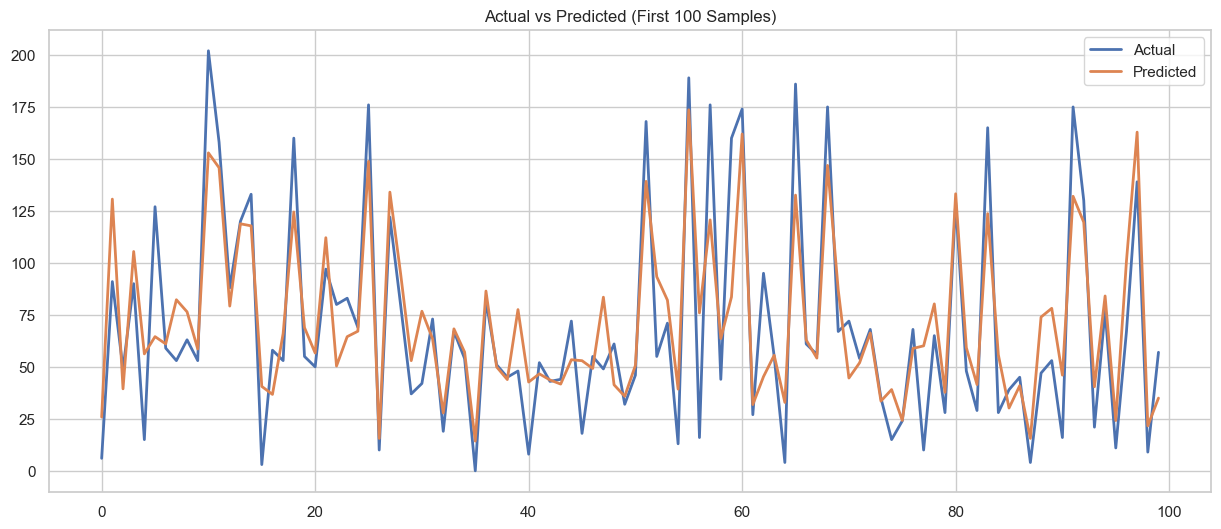

In [29]:
# ==============================================================================
# ACTUAL VS PREDICTED LINE GRAPH
# ==============================================================================

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:100],
    label="Actual",
    linewidth=2
)

plt.plot(
    y_test_pred[:100],
    label="Predicted",
    linewidth=2
)

plt.legend()

plt.title("Actual vs Predicted (First 100 Samples)")

plt.show()

In [30]:
# ==============================================================================
# SAVE KNN MODEL
# ==============================================================================

import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    knn_model,
    "model/knn_model.pkl"
)

print("KNN Model Saved Successfully")

KNN Model Saved Successfully


In [31]:
# ==============================================================================
# SAVE SCALER
# ==============================================================================

joblib.dump(
    scaler,
    "model/knn_scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [32]:
# ==============================================================================
# SAVE PREDICTIONS
# ==============================================================================

os.makedirs("dataset", exist_ok=True)

prediction_df.to_csv(
    "dataset/knn_predictions.csv",
    index=False
)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


In [33]:
# ==============================================================================
# SAVE PERFORMANCE REPORT
# ==============================================================================

summary.to_csv(
    "dataset/KNN_Performance.csv",
    index=False
)

print("Performance Report Saved Successfully")

Performance Report Saved Successfully


In [34]:
# ==============================================================================
# VERIFY MODEL FILES
# ==============================================================================

print(os.listdir("model"))

['catboost_model.pkl', 'decision_tree.pkl', 'knn_model.pkl', 'knn_scaler.pkl', 'label_encoder.pkl', 'lightgbm_model.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'svr_model.pkl', 'svr_scaler.pkl', 'xgboost_model.pkl']


In [35]:
# ==============================================================================
# VERIFY DATASET FILES
# ==============================================================================

print(os.listdir("dataset"))

['CatBoost_Performance.csv', 'catboost_predictions.csv', 'DecisionTree_Performance.csv', 'decision_tree_predictions.csv', 'KNN_Performance.csv', 'knn_predictions.csv', 'LightGBM_Performance.csv', 'lightgbm_predictions.csv', 'Linear_Regression_Performance.csv', 'linear_regression_predictions.csv', 'RandomForest_Performance.csv', 'random_forest_predictions.csv', 'SVR_Performance.csv', 'svr_predictions.csv', 'XGBoost_Performance.csv', 'xgboost_predictions.csv']


In [36]:
# ==============================================================================
# BUSINESS INTERPRETATION
# ==============================================================================

print("Business Interpretation")

print("- KNN predicts demand based on similar historical records.")
print("- Feature scaling significantly improves KNN performance.")
print("- It is simple, interpretable, and effective on moderate-sized datasets.")
print("- Performance depends on the value of K and the distance metric.")

Business Interpretation
- KNN predicts demand based on similar historical records.
- Feature scaling significantly improves KNN performance.
- It is simple, interpretable, and effective on moderate-sized datasets.
- Performance depends on the value of K and the distance metric.


In [37]:
# ==============================================================================
# MODEL SUMMARY
# ==============================================================================

print("="*60)

print("KNN REGRESSION MODEL SUMMARY")

print("="*60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("Features Used    :", X_train.shape[1])

print("="*60)

KNN REGRESSION MODEL SUMMARY
Training Samples : 6880
Testing Samples  : 1721
Features Used    : 30


In [38]:
# ==============================================================================
# DISPLAY PERFORMANCE SUMMARY
# ==============================================================================

display(summary)

,Metric,Value
0,MAE,20.988313
1,MSE,750.209222
2,RMSE,27.389947
3,R²,0.736415
4,Adjusted R²,0.731736
5,MAPE,inf
6,Cross Validation,0.745400
